# Meet The Kaggle Team

[Meta Kaggle](https://kaggle.com/kaggle/meta-kaggle) is "Kaggle's public data on competitions, users, submission scores, and kernels". There is actually a "Meet Our Team" page on Kaggle already: https://kaggle.com/about/team. However, not every Kaggle team member is listed. Also, the Meta Kaggle dataset allows us to go into a bit more detail.

<a id="table-of-contents"></a>

## Table of contents
1. [The Kaggle team](#the-kaggle-team)
1. [Where are Kaggle team members located?](#location)
1. [Followers](#followers)
1. [Discussions](#discussions)
1. [Competitions](#comps)
1. [Kernels](#kernels)
1. [Datasets](#datasets)

In [1]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

In [2]:
import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
import time
import re
import json

import seaborn as sns
import matplotlib.pyplot as plt

from geopandas.tools import geocode
import folium
from folium import Marker
from folium.plugins import MarkerCluster

from IPython.display import display, HTML
        
KAGGLE_BASE_URL = "https://kaggle.com/"
TOP_N = 10
REQUEST_DELAY = 2

In [3]:
# # Datasets
datasets = pd.read_csv('/kaggle/input/meta-kaggle/Datasets.csv', 
                       parse_dates=['CreationDate', 'ReviewDate', 'FeatureDate',
                                    'LastActivityDate'], infer_datetime_format=True
                      )
dataset_versions = pd.read_csv('/kaggle/input/meta-kaggle/DatasetVersions.csv', 
                               parse_dates=['CreationDate'], 
                               infer_datetime_format=True
                              )
# dataset_votes = pd.read_csv('/kaggle/input/meta-kaggle/DatasetVotes.csv', 
#                             parse_dates=['VoteDate'], infer_datetime_format=True
#                            )
# dataset_tags = pd.read_csv('/kaggle/input/meta-kaggle/DatasetTags.csv')
# data_sources = pd.read_csv('/kaggle/input/meta-kaggle/Datasources.csv', 
#                            parse_dates=['CreationDate'], infer_datetime_format=True
#                           )

# # Kernels
kernels = pd.read_csv('/kaggle/input/meta-kaggle/Kernels.csv', 
                      parse_dates=['CreationDate', 'EvaluationDate',
                                   'MadePublicDate', 'MedalAwardDate'],
                      infer_datetime_format=True
                     )
kernel_versions = pd.read_csv('/kaggle/input/meta-kaggle/KernelVersions.csv', 
                              parse_dates=['CreationDate', 'EvaluationDate'],
                              infer_datetime_format=True
                             )
# kernel_votes = pd.read_csv('/kaggle/input/meta-kaggle/KernelVotes.csv', 
#                            parse_dates=['VoteDate'], infer_datetime_format=True
#                           )
# kernel_version_comp = pd.read_csv('/kaggle/input/meta-kaggle/KernelVersionCompetitionSources.csv')
# kernel_version_out = pd.read_csv('/kaggle/input/meta-kaggle/KernelVersionOutputFiles.csv')
# kernel_version_datasets = pd.read_csv('/kaggle/input/meta-kaggle/KernelVersionDatasetSources.csv')
# kernel_langs = pd.read_csv('/kaggle/input/meta-kaggle/KernelLanguages.csv')
# kernel_version_kernel_sources = pd.read_csv('/kaggle/input/meta-kaggle/KernelVersionKernelSources.csv')
# kernel_tags = pd.read_csv('/kaggle/input/meta-kaggle/KernelTags.csv')

# # Forums
messages = pd.read_csv('/kaggle/input/meta-kaggle/ForumMessages.csv', 
                       parse_dates=['PostDate', 'MedalAwardDate'], 
                       infer_datetime_format=True
                      )
topics = pd.read_csv('/kaggle/input/meta-kaggle/ForumTopics.csv', 
                     parse_dates=['CreationDate', 'LastCommentDate'], 
                     infer_datetime_format=True
                    )
# forums = pd.read_csv('/kaggle/input/meta-kaggle/Forums.csv')
# forum_votes = pd.read_csv('/kaggle/input/meta-kaggle/ForumMessageVotes.csv', 
#                           parse_dates=['VoteDate'], infer_datetime_format=True
#                          )

# # Competitions
# teams = pd.read_csv('/kaggle/input/meta-kaggle/Teams.csv', 
#                     parse_dates=['ScoreFirstSubmittedDate', 'LastSubmissionDate',
#                                  'MedalAwardDate'], 
#                     infer_datetime_format=True
#                    )
# comps = pd.read_csv('/kaggle/input/meta-kaggle/Competitions.csv', 
#                     parse_dates=['EnabledDate', 'DeadlineDate', 
#                                  'ProhibitNewEntrantsDeadlineDate', 'TeamMergerDeadlineDate', 
#                                  'TeamModelDeadlineDate', 'ModelSubmissionDeadlineDate'], 
#                     infer_datetime_format=True
#                    )
# comp_tags = pd.read_csv('/kaggle/input/meta-kaggle/CompetitionTags.csv')
# team_membership = pd.read_csv('/kaggle/input/meta-kaggle/TeamMemberships.csv', 
#                               parse_dates=['RequestDate'], 
#                               infer_datetime_format=True
#                              )
# submissions = pd.read_csv('/kaggle/input/meta-kaggle/Submissions.csv', 
#                           parse_dates=['SubmissionDate', 'ScoreDate'], 
#                           infer_datetime_format=True
#                          )

# # Users
users = pd.read_csv('/kaggle/input/meta-kaggle/Users.csv',
                    parse_dates=['RegisterDate'], 
                    infer_datetime_format=True
                   )
user_followers = pd.read_csv('/kaggle/input/meta-kaggle/UserFollowers.csv', 
                             parse_dates=['CreationDate'], 
                             infer_datetime_format=True
                            )
# user_orgs = pd.read_csv('/kaggle/input/meta-kaggle/UserOrganizations.csv', 
#                         parse_dates=['JoinDate'], 
#                         infer_datetime_format=True
#                        )
# user_ach = pd.read_csv('/kaggle/input/meta-kaggle/UserAchievements.csv', 
#                        parse_dates=['TierAchievementDate'], 
#                        infer_datetime_format=True
#                       )

# # Misc
# tags = pd.read_csv('/kaggle/input/meta-kaggle/Tags.csv')
# orgs = pd.read_csv('/kaggle/input/meta-kaggle/Organizations.csv', 
#                    parse_dates=['CreationDate'], infer_datetime_format=True
#                   )

In [4]:
kaggle_team = (users[users['PerformanceTier'].eq(5)]
               .copy()
               .reset_index(drop=True)
               .drop(columns='PerformanceTier')
              )

In [5]:
string = f"There are currently {kaggle_team.shape[0]} employees on the Kaggle team."
display(HTML(string))

<a id="the-kaggle-team"></a>
[Return to table of contents](#table-of-contents)

# The Kaggle Team
The images in the table below link to the Kaggle team member's profile. A missing location or occupation in the table indicates that the Kaggle team member has not filled in this information in their profile.

In [6]:
def display_html(df, cols=None, num_rows=0):
    """Display columns cols and num_rows rows of the data 
    frame df in HTML.
    """
    
    if num_rows != 0:
        df_to_display = df.head(num_rows)
    else:
        df_to_display = df
    
    df_html = df_to_display.to_html(columns=cols, index=False, na_rep='',
                              escape=False, render_links=True)
    display(HTML(df_html))

In [7]:
for index in kaggle_team.index:
    time.sleep(REQUEST_DELAY)
    row = kaggle_team.iloc[index]
    
    username = row.UserName
    profile_url = f'{KAGGLE_BASE_URL}{username}'
    displayname = row.DisplayName
    
    result = requests.get(profile_url)
    src = result.text
    soup = BeautifulSoup(src, 'html.parser').find_all("div", id="site-body")[0].find("script")
    
    user_info = re.search('Kaggle.State.push\(({.*})', str(soup)).group(1)
    user_dict = json.loads(user_info)

    city = user_dict['city']
    region = user_dict['region']
    country = user_dict['country']
    avatar_url = user_dict['userAvatarUrl']
    occupation = user_dict['occupation']
    organization = user_dict['organization']
    num_followers = user_dict['followers']['count']
    num_following = user_dict['following']['count']
    num_posts = user_dict['discussionsSummary']['totalResults']
    num_datasets = user_dict['datasetsSummary']['totalResults']
    num_kernels = user_dict['scriptsSummary']['totalResults']
    num_comps = user_dict['competitionsSummary']['totalResults']
    
    
    kaggle_team.loc[index, 'Image'] = f'<a href="{profile_url}" target="_blank" title="{displayname}"><img src="{avatar_url}" width="100" height="100"></a>'
    
    if city and region and country:
        kaggle_team.loc[index, 'Location'] = f'{city}, {region}, {country}'
        
    if occupation and organization:
        kaggle_team.loc[index, 'Occupation'] = f'{occupation} at {organization}'
    elif organization:
        kaggle_team.loc[index, 'Occupation'] = organization
    elif occupation:
        kaggle_team.loc[index, 'Occupation'] = occupation
    
    kaggle_team.loc[index, 'NumFollowers'] = num_followers
    kaggle_team.loc[index, 'NumFollowing'] = num_following
    kaggle_team.loc[index, 'NumPosts'] = num_posts
    kaggle_team.loc[index, 'NumDatasets'] = num_datasets
    kaggle_team.loc[index, 'NumKernels'] = num_kernels
    kaggle_team.loc[index, 'NumCompetitions'] = num_comps

kaggle_team = kaggle_team.convert_dtypes()
display_html(kaggle_team, cols=['UserName', 'DisplayName', 'RegisterDate',
                                'Image', 'Location', 'Occupation'])

UserName,DisplayName,RegisterDate,Image,Location,Occupation
kaggleteam,Kaggle Team,2011-03-24,,,
antgoldbloom,Anthony Goldbloom,2010-01-20,,"San Francisco, California, United States",CEO at Kaggle
benhamner,Ben Hamner,2010-05-31,,"San Francisco, California, United States",Co-founder and CTO at Kaggle
jeffmoser,Jeff Moser,2010-08-21,,"Zionsville, Indiana, United States",Developer at Kaggle
wcukierski,William Cukierski,2010-10-13,,,Head of Competitions at Kaggle
wendykan,Wendy Kan,2012-04-01,,"San Francisco, California, United States",Data Scientist at Kaggle
inversion,inversion,2012-09-21,,"Neenah, Wisconsin, United States",Data Scientist at Kaggle
philculliton,Phil Culliton,2013-07-22,,"Buffalo, New York, United States",Data Scientist at Kaggle
jeradrose,Jerad Rose,2014-05-12,,"Louisville, Kentucky, United States",Developer at Kaggle
annavictoria,Anna Montoya,2014-11-17,,"Oakland, California, United States",Marketing at Kaggle


<a id="location"></a>
[Return to table of contents](#table-of-contents)

# Where are Kaggle team members located?
The [Geospatial Analysis](https://kaggle.com/learn/geospatial-analysis) course on Kaggle was one of my favourites. We'll put that knowledge to use here to geocode the locations from the table above.

In [8]:
m = folium.Map(location=[0, 30], tiles='OpenStreetMap', zoom_start=1)
mc = MarkerCluster()
locations = {}
for index in kaggle_team[kaggle_team.Location.notna()].index:
    time.sleep(REQUEST_DELAY)
    row = kaggle_team.iloc[index]
    displayname = row.DisplayName
    location = row.Location
    popup = f'{displayname}; {location}'
    tooltip = f'{displayname}; {location}'
    
    if location in locations:
        lat, long = locations[location]
    else:
        point = geocode(location, provider='nominatim').geometry.iloc[0]
        lat, long = point.y, point.x
        locations[location] = [lat, long]
    
    mc.add_child(Marker([lat, long], popup=popup, tooltip=tooltip))
    
m.add_child(mc)

As expected, most Kaggle team members are in the United States.

<a id="followers"></a>
[Return to table of contents](#table-of-contents)

# Followers

### Who has the most followers?
Meg has more than twice as many followers as anyone else on the Kaggle team!

In [9]:
followers = kaggle_team.nlargest(TOP_N, 'NumFollowers').copy()
display_html(followers, cols=['UserName', 'DisplayName', 'Image',
                              'Occupation', 'NumFollowers', 'NumFollowing'])

UserName,DisplayName,Image,Occupation,NumFollowers,NumFollowing
mrisdal,Meg Risdal,,Product Manager at Kaggle,2979,121
alexisbcook,Alexis Cook,,Head of Kaggle Learn at Kaggle,1410,15
benhamner,Ben Hamner,,Co-founder and CTO at Kaggle,1186,22
inversion,inversion,,Data Scientist at Kaggle,931,23
paultimothymooney,Paul Mooney,,Developer Advocate at Kaggle,844,416
wcukierski,William Cukierski,,Head of Competitions at Kaggle,692,30
wendykan,Wendy Kan,,Data Scientist at Kaggle,640,8
antgoldbloom,Anthony Goldbloom,,CEO at Kaggle,628,5
jessicali9530,Jessica Li,,Product Manager at Kaggle,379,17
sohier,Sohier Dane,,Data Scientist at Kaggle,332,5


### Who follows other users the most?
Paul follows more than twice as many users as anyone else on the Kaggle team!

In [10]:
following = kaggle_team.nlargest(TOP_N, 'NumFollowing').copy()
display_html(following, cols=['UserName', 'DisplayName', 'Image',
                              'Occupation', 'NumFollowing', 'NumFollowers'])

UserName,DisplayName,Image,Occupation,NumFollowing,NumFollowers
paultimothymooney,Paul Mooney,,Developer Advocate at Kaggle,416,844
mylesoneill,Myles O'Neill,,Designer at Kaggle,152,290
mrisdal,Meg Risdal,,Product Manager at Kaggle,121,2979
jplotts,Jim Plotts,,Developer at Kaggle,32,20
ryanholbrook,Ryan Holbrook,,AI Educator at Kaggle Learn,32,10
wcukierski,William Cukierski,,Head of Competitions at Kaggle,30,692
timoboz,Timo Bozsolik,,Developer at Kaggle,30,153
inversion,inversion,,Data Scientist at Kaggle,23,931
zachdiemer,Zach Diemer,,Software Engineer at Kaggle,23,11
benhamner,Ben Hamner,,Co-founder and CTO at Kaggle,22,1186


Next, we will break down followers and follows by tiers.
### Who does the Kaggle team follow?

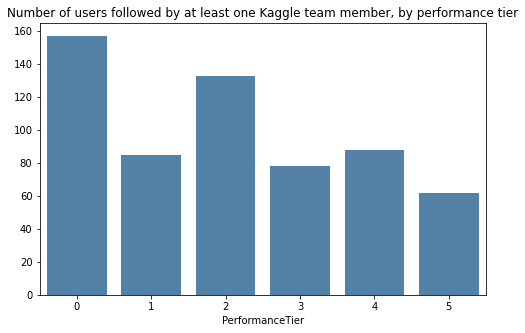

In [11]:
kaggle_following_tier = (pd.merge(user_followers[['UserId', 'FollowingUserId']], kaggle_team['Id'], left_on='UserId', right_on='Id')
                         .drop(columns='Id')
                         .merge(users, left_on='FollowingUserId', right_on='Id')[['Id', 'UserName', 'DisplayName', 'PerformanceTier']]
                         .drop_duplicates('Id')
                         .groupby('PerformanceTier')
                         .size()
                        )
plt.figure(figsize=(8, 5))
plt.title('Number of users followed by at least one Kaggle team member, by performance tier')
ax = sns.barplot(kaggle_following_tier.index, kaggle_following_tier.values, color='steelblue')

Of all users that are followed by Kaggle team members, most are novices. If we look at the number of users on the platform by performance tier, we see that most users are novices. We'll divide the counts by the number of users in that tier and visualize the proportion of users in a tier that are followed by at least one Kaggle team member.

In [12]:
tier_counts = users['PerformanceTier'].value_counts()
tier_counts

0    5105738
1      86648
2       6802
3       1535
4        218
5         65
Name: PerformanceTier, dtype: int64

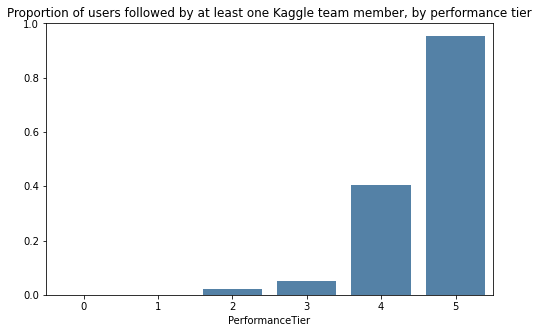

In [13]:
kaggle_following_tier_prop = kaggle_following_tier / tier_counts
plt.figure(figsize=(8, 5))
plt.title('Proportion of users followed by at least one Kaggle team member, by performance tier')
ax = sns.barplot(kaggle_following_tier_prop.index, kaggle_following_tier_prop.values, color='steelblue')

Almost every Kaggle team member is followed by another Kaggle team member. Also, about 40% of grandmasters are followed by at least one Kaggle team member.

### Who follows the Kaggle team?

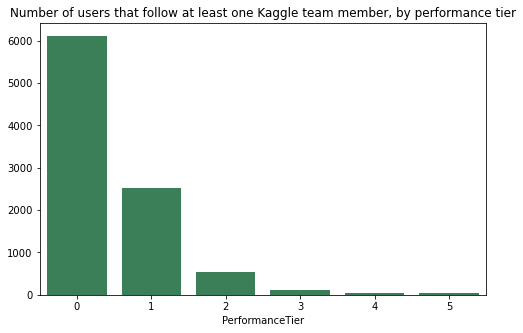

In [14]:
kaggle_followers_tier = (pd.merge(user_followers[['UserId', 'FollowingUserId']], kaggle_team['Id'], left_on='FollowingUserId', right_on='Id')
                         .drop(columns='Id')
                         .merge(users, left_on='UserId', right_on='Id')[['Id', 'UserName', 'DisplayName', 'PerformanceTier']]
                         .drop_duplicates('Id')
                         .groupby('PerformanceTier')
                         .size()
                        )
plt.figure(figsize=(8, 5))
plt.title('Number of users that follow at least one Kaggle team member, by performance tier')
ax = sns.barplot(kaggle_followers_tier.index, kaggle_followers_tier.values, color='seagreen')

As expected, most users that follow the Kaggle team are novices. Just as we did above, we'll visualize the proportion of users that follow at least one Kaggle team member, by performance tier.

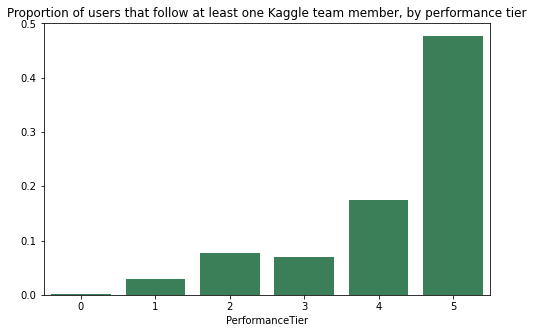

In [15]:
kaggle_followers_tier_prop = kaggle_followers_tier / tier_counts
plt.figure(figsize=(8, 5))
plt.title('Proportion of users that follow at least one Kaggle team member, by performance tier')
ax = sns.barplot(kaggle_followers_tier_prop.index, kaggle_followers_tier_prop.values, color='seagreen')

For the most part, the higher a user's tier, the more likely they are to follow at least one Kaggle team member.

<a id="discussions"></a>
[Return to table of contents](#table-of-contents)

# Discussions
### Number of posts by the Kaggle team


In [16]:
kaggle_team_posts = kaggle_team[['UserName', 'DisplayName', 'Image', 'Occupation', 'NumPosts']].nlargest(TOP_N, 'NumPosts').copy()
display_html(kaggle_team_posts)

UserName,DisplayName,Image,Occupation,NumPosts
wcukierski,William Cukierski,,Head of Competitions at Kaggle,2396
inversion,inversion,,Data Scientist at Kaggle,2179
paultimothymooney,Paul Mooney,,Developer Advocate at Kaggle,1918
benhamner,Ben Hamner,,Co-founder and CTO at Kaggle,1777
mrisdal,Meg Risdal,,Product Manager at Kaggle,1487
addisonhoward,Addison Howard,,Program Manager at Kaggle,926
juliaelliott,Julia Elliott,,Customer Success at Kaggle,838
herbison,Dustin,,Software Engineer (Notebooks Backend) at Kaggle,813
wendykan,Wendy Kan,,Data Scientist at Kaggle,704
mylesoneill,Myles O'Neill,,Designer at Kaggle,644


### Popular topics by the Kaggle team

In [17]:
forum_topics = (topics[topics.KernelId.isna()]
                .merge(messages[['Id', 'PostUserId']], left_on='FirstForumMessageId', right_on='Id')
                .loc[:, ['Title', 'Score', 'TotalMessages', 'TotalReplies', 'PostUserId']]
                .merge(kaggle_team, left_on='PostUserId', right_on='Id')
                .nlargest(TOP_N, 'Score')
               )

display_html(forum_topics,
             cols=['UserName', 'DisplayName', 'Image', 'Occupation', 'Score', 'Title']
            )

UserName,DisplayName,Image,Occupation,Score,Title
mrisdal,Meg Risdal,,Product Manager at Kaggle,342,Resources for a new data project
alexisbcook,Alexis Cook,,Head of Kaggle Learn at Kaggle,320,Just launched: Course certificates
mrisdal,Meg Risdal,,Product Manager at Kaggle,269,New Weekly $500 Award for Kernels on Datasets + Q&A
antgoldbloom,Anthony Goldbloom,,CEO at Kaggle,242,Introducing Community Guidelines for Kaggle
inversion,inversion,,Data Scientist at Kaggle,148,Data Leak and Next Steps
inversion,inversion,,Data Scientist at Kaggle,142,My Standard Work for every new competition
devvret,devrishi,,Product Manager at Google,125,"Introducing Tasks to Kaggle Datasets, a new way to engage"
wcukierski,William Cukierski,,Head of Competitions at Kaggle,122,Video Tutorial
devvret,devrishi,,Product Manager at Google,121,Bringing Kaggle’s Progression to our Datasets Platform
mylesoneill,Myles O'Neill,,Designer at Kaggle,109,Kernel & Forum Moderation - New Report System


<a id="comps"></a>
[Return to table of contents](#table-of-contents)

# Competitions
### Number of competitions

In [18]:
kaggle_team_comps = kaggle_team[['UserName', 'DisplayName', 'Image', 'Occupation', 'NumCompetitions']].nlargest(TOP_N, 'NumCompetitions').copy()
display_html(kaggle_team_comps)

UserName,DisplayName,Image,Occupation,NumCompetitions
inversion,inversion,,Data Scientist at Kaggle,78
benhamner,Ben Hamner,,Co-founder and CTO at Kaggle,53
philculliton,Phil Culliton,,Data Scientist at Kaggle,40
antgoldbloom,Anthony Goldbloom,,CEO at Kaggle,20
wcukierski,William Cukierski,,Head of Competitions at Kaggle,19
wendykan,Wendy Kan,,Data Scientist at Kaggle,18
jeffmoser,Jeff Moser,,Developer at Kaggle,11
paultimothymooney,Paul Mooney,,Developer Advocate at Kaggle,8
mrisdal,Meg Risdal,,Product Manager at Kaggle,7
mbooth,Michael Booth,,Software Engineer at Kaggle,5


<a id="kernels"></a>
[Return to table of contents](#table-of-contents)

# Kernels
### Number of kernels
Of course, Kaggle Kerneler is at the top.

In [19]:
kaggle_team_kernels = kaggle_team[['UserName', 'DisplayName', 'Image', 'Occupation', 'NumKernels']].nlargest(TOP_N, 'NumKernels').copy()
display_html(kaggle_team_kernels)

UserName,DisplayName,Image,Occupation,NumKernels
kerneler,Kaggle Kerneler,,Kaggle,41133
benhamner,Ben Hamner,,Co-founder and CTO at Kaggle,867
paultimothymooney,Paul Mooney,,Developer Advocate at Kaggle,205
antgoldbloom,Anthony Goldbloom,,CEO at Kaggle,176
mrisdal,Meg Risdal,,Product Manager at Kaggle,169
jeffmoser,Jeff Moser,,Developer at Kaggle,148
alexisbcook,Alexis Cook,,Head of Kaggle Learn at Kaggle,103
wcukierski,William Cukierski,,Head of Competitions at Kaggle,61
sohier,Sohier Dane,,Data Scientist at Kaggle,50
skbergam,Sean Bergam,,Software Engineer at Kaggle,49


### Popular kernels by the Kaggle team

In [20]:
kaggle_team_kernels = (pd.merge(kaggle_team[['Id', 'UserName', 'DisplayName', 'Image']], 
                               kernels[['Id', 'AuthorUserId', 'CurrentKernelVersionId', 'TotalVotes', 'CurrentUrlSlug']], 
                               left_on='Id', right_on='AuthorUserId')
                       .nlargest(TOP_N, 'TotalVotes')
                       .merge(kernel_versions[['Title', 'Id']], left_on='CurrentKernelVersionId', right_on='Id')
                      )
kaggle_team_kernels['url'] = KAGGLE_BASE_URL + kaggle_team_kernels.UserName + '/' + kaggle_team_kernels.CurrentUrlSlug
display_html(kaggle_team_kernels, cols=['UserName', 'DisplayName', 'Image', 'TotalVotes', 'Title', 'url'])

UserName,DisplayName,Image,TotalVotes,Title,url
mrisdal,Meg Risdal,,3371,Exploring Survival on the Titanic,https://kaggle.com/mrisdal/exploring-survival-on-the-titanic
alexisbcook,Alexis Cook,,2265,Titanic Tutorial,https://kaggle.com/alexisbcook/titanic-tutorial
benhamner,Ben Hamner,,1098,Python Data Visualizations,https://kaggle.com/benhamner/python-data-visualizations
dster,DJ Sterling,,981,Two Sigma News Official Getting Started Kernel,https://kaggle.com/dster/two-sigma-news-official-getting-started-kernel
alexisbcook,Alexis Cook,,580,Missing Values,https://kaggle.com/alexisbcook/missing-values
alexisbcook,Alexis Cook,,516,"Hello, Seaborn",https://kaggle.com/alexisbcook/hello-seaborn
annavictoria,Anna Montoya,,466,ML-friendly Public Datasets,https://kaggle.com/annavictoria/ml-friendly-public-datasets
alexisbcook,Alexis Cook,,441,Categorical Variables,https://kaggle.com/alexisbcook/categorical-variables
sohier,Sohier Dane,,371,Tutorial: Accessing Data with Pandas,https://kaggle.com/sohier/tutorial-accessing-data-with-pandas
alexisbcook,Alexis Cook,,348,Pipelines,https://kaggle.com/alexisbcook/pipelines


<a id="datasets"></a>
[Return to table of contents](#table-of-contents)

# Datasets
### Number of datasets

In [21]:
kaggle_team_data = kaggle_team[['UserName', 'DisplayName', 'Image', 'Occupation', 'NumDatasets']].nlargest(TOP_N, 'NumDatasets').copy()
display_html(kaggle_team_data)

UserName,DisplayName,Image,Occupation,NumDatasets
paultimothymooney,Paul Mooney,,Developer Advocate at Kaggle,49
sohier,Sohier Dane,,Data Scientist at Kaggle,28
jessemostipak,Jesse Mostipak,,Community Advocate at Kaggle,17
mylesoneill,Myles O'Neill,,Designer at Kaggle,16
ryanholbrook,Ryan Holbrook,,AI Educator at Kaggle Learn,16
mrisdal,Meg Risdal,,Product Manager at Kaggle,15
timoboz,Timo Bozsolik,,Developer at Kaggle,15
antgoldbloom,Anthony Goldbloom,,CEO at Kaggle,12
benhamner,Ben Hamner,,Co-founder and CTO at Kaggle,12
jessicali9530,Jessica Li,,Product Manager at Kaggle,11


### Popular datasets by the Kaggle team

In [22]:
kaggle_team_datasets = (datasets[datasets.OwnerUserId.notna() & datasets.OwnerUserId.eq(datasets.CreatorUserId)]
                        .loc[:, ['Id', 'CreatorUserId', 'TotalVotes', 'CurrentDatasetVersionId']]
                        .merge(kaggle_team[['Id', 'UserName', 'DisplayName', 'Image']], left_on='CreatorUserId', right_on='Id')
                        .nlargest(TOP_N, 'TotalVotes')
                        .merge(dataset_versions[['Id', 'Title', 'Slug']], left_on='CurrentDatasetVersionId', right_on='Id')                        
                       )
kaggle_team_datasets['url'] = KAGGLE_BASE_URL + kaggle_team_datasets.UserName + '/' + kaggle_team_datasets.Slug
display_html(kaggle_team_datasets, cols=['UserName', 'DisplayName', 'Image', 'TotalVotes', 'Title', 'url'])

UserName,DisplayName,Image,TotalVotes,Title,url
paultimothymooney,Paul Mooney,,2426,Chest X-Ray Images (Pneumonia),https://kaggle.com/paultimothymooney/chest-xray-pneumonia
timoboz,Timo Bozsolik,,1224,Data Science Cheat Sheets,https://kaggle.com/timoboz/data-science-cheat-sheets
jessemostipak,Jesse Mostipak,,932,Hotel booking demand,https://kaggle.com/jessemostipak/hotel-booking-demand
mylesoneill,Myles O'Neill,,750,Game of Thrones,https://kaggle.com/mylesoneill/game-of-thrones
jessicali9530,Jessica Li,,689,CelebFaces Attributes (CelebA) Dataset,https://kaggle.com/jessicali9530/celeba-dataset
mylesoneill,Myles O'Neill,,648,World University Rankings,https://kaggle.com/mylesoneill/world-university-rankings
annavictoria,Anna Montoya,,626,Speed Dating Experiment,https://kaggle.com/annavictoria/speed-dating-experiment
jessicali9530,Jessica Li,,531,Stanford Dogs Dataset,https://kaggle.com/jessicali9530/stanford-dogs-dataset
paultimothymooney,Paul Mooney,,491,Blood Cell Images,https://kaggle.com/paultimothymooney/blood-cells
wcukierski,William Cukierski,,480,The Enron Email Dataset,https://kaggle.com/wcukierski/enron-email-dataset
